<a href="https://colab.research.google.com/github/SamM-UATX/torchlight-hackathon-2026/blob/main/torchlight_full_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚀 Torchlight Hackathon 2026 — Full 12-Dataset Integrated Risk Profile
**Track 02: Individualized Risk Profile**

Complete multi-omics analysis of the 2021 Inspiration4 mission across all biological layers:
microbiome → metabolome → proteome → immune system → genome → epigenome

| Layer | Datasets | OSD IDs |
|-------|----------|--------|
| 🦠 Microbiome | Body swabs (KO, taxonomy, pathway, gene family) | OSD-572 |
| 🧫 Gut Microbiome | Stool metagenomics (KO, taxonomy, pathway, gene family) | OSD-630 |
| 🚀 Environment | Dragon capsule swabs | OSD-573 |
| 🩸 Blood Chemistry | Metabolic panel + CBC | OSD-575, OSD-569 |
| 💊 Cytokines | Immune + cardiac cytokine arrays (3 panels) | OSD-575 |
| 🧪 Metabolomics | Plasma metabolites | OSD-571 |
| 🔬 Proteomics | Plasma + EVP proteins | OSD-571 |
| 💧 Urine | 203 inflammatory proteins | OSD-656 |
| 🧬 RNA-seq | Whole blood gene expression | OSD-569 |
| 🔓 Epigenome | m6A modification + snATAC-seq chromatin | OSD-569, OSD-570 |
| 🛡️ Immune Repertoire | T-cell & B-cell VDJ clones | OSD-570 |
| 🩹 Skin | Spatial transcriptomics + deltoid microbiome | OSD-574 |


## 0. Setup & Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (16, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

CREW_IDS       = ['C001', 'C002', 'C003', 'C004']
PRE_FLIGHT     = ['L-92', 'L-44', 'L-3']
IN_FLIGHT      = ['FD2', 'FD3']
POST_FLIGHT    = ['R+1', 'R+45', 'R+82']
TIMEPOINT_ORDER = PRE_FLIGHT + IN_FLIGHT + POST_FLIGHT
COLORS = {'C001':'#E63946','C002':'#457B9D','C003':'#2A9D8F','C004':'#E9C46A'}
EPSILON = 1e-6

SITE_NAMES = {
    'ARM':'Volar Forearm','EAR':'Post-Auricular','GLU':'Gluteal Crease',
    'NAC':'Nasal Cavity','NAP':'Nasal Passage','ORC':'Oral Cavity',
    'PIT':'Axillary Vault','TZO':'Toe Web','UMB':'Umbilicus',
    'WEB':'Glabella','DEL':'Deltoid'
}

def crew_cols(df, crew, timepoints=None):
    """Get columns for a crew member, optionally filtered by timepoints."""
    out = []
    for col in df.columns:
        parts = str(col).split('_')
        if len(parts) >= 2 and parts[0] == crew:
            if timepoints is None or parts[1] in timepoints:
                out.append(col)
    return out

def tp_cols(df, crew, tp):
    return [c for c in df.columns if str(c).startswith(f'{crew}_{tp}_') or str(c) == f'{crew}_{tp}']

def personal_baseline(df, crew):
    """Mean across all pre-flight columns for a crew member."""
    pre = crew_cols(df, crew, PRE_FLIGHT)
    if not pre:
        pre = crew_cols(df, crew)
        pre = pre[:max(1, len(pre)//4)]
    return df[pre].mean(axis=1)

def deviation_score(sample_series, baseline_series):
    """Normalized mean absolute deviation from baseline (%)."""
    diff = (sample_series - baseline_series).abs()
    norm = baseline_series.abs() + EPSILON
    return (diff / norm).mean() * 100

def compute_deviations(df, label=''):
    """Compute deviation scores for all crew × all timepoints."""
    rows = []
    for crew in CREW_IDS:
        baseline = personal_baseline(df, crew)
        row = {'crew': crew}
        for tp in TIMEPOINT_ORDER:
            cols = tp_cols(df, crew, tp)
            if cols:
                tp_mean = df[cols].mean(axis=1)
                row[tp] = deviation_score(tp_mean, baseline)
            else:
                row[tp] = np.nan
        rows.append(row)
    result = pd.DataFrame(rows).set_index('crew')
    if label:
        print(f'  ✅ {label}: deviations computed')
    return result

print('✅ Setup complete')

✅ Setup complete


## 1. Load All 12 Datasets
Loading all data sources from NASA OSDR across all biological layers.

### 1.1 Dataset 1 — Oral/Nasal/Skin Microbial Swabs (OSD-572)

In [ ]:
BASE572 = 'https://osdr.nasa.gov/geode-py/ws/studies/OSD-572/download?source=datamanager&file='

print('Loading OSD-572: Body swab metagenomics...')
kegg_swab = pd.read_csv(BASE572 + 'GLDS-564_GMetagenomics_Combined-gene-level-KO-function-coverages_GLmetagenomics.tsv', index_col=0, sep='\t')
kegg_swab = kegg_swab[[c for c in kegg_swab.columns if any(cr in c for cr in CREW_IDS)]]
print(f'  KEGG swab: {kegg_swab.shape}')

tax_swab = pd.read_csv(BASE572 + 'GLDS-564_GMetagenomics_Combined-gene-level-taxonomy-coverages-CPM_GLmetagenomics.tsv', index_col=0, sep='\t', low_memory=False)
tax_swab = tax_swab[[c for c in tax_swab.columns if any(cr in c for cr in CREW_IDS)]]
print(f'  Taxonomy swab: {tax_swab.shape}')

pathway_swab = pd.read_csv(BASE572 + 'GLDS-564_GMetagenomics_Pathway-abundances-cpm_GLmetagenomics.tsv', index_col=0, sep='\t')
pathway_swab = pathway_swab[[c for c in pathway_swab.columns if any(cr in c for cr in CREW_IDS)]]
pathway_swab.columns = [c.replace('_Abundance-CPM','') for c in pathway_swab.columns]
print(f'  Pathway swab: {pathway_swab.shape}')

genefam_swab = pd.read_csv(BASE572 + 'GLDS-564_GMetagenomics_Gene-families-cpm_GLmetagenomics.tsv', index_col=0, sep='\t')
genefam_swab = genefam_swab[[c for c in genefam_swab.columns if any(cr in c for cr in CREW_IDS)]]
genefam_swab.columns = [c.replace('_Abundance-CPM','') for c in genefam_swab.columns]
print(f'  Gene family swab: {genefam_swab.shape}')
print('✅ Dataset 1 loaded')

Loading OSD-572: Body swab metagenomics...
  KEGG swab: (10537, 323)
  Taxonomy swab: (18850, 323)
  Pathway swab: (567, 325)
  Gene family swab: (908967, 325)
✅ Dataset 1 loaded


### 1.2 Dataset 2 — Blood Serum Metabolic Panel (OSD-575)

In [ ]:
BASE575 = 'https://osdr.nasa.gov/geode-py/ws/studies/OSD-575/download?source=datamanager&file='
print('Loading OSD-575: Blood serum metabolic panel...')
try:
    metabolic_blood = pd.read_csv(BASE575 + 'GLDS-567_metabolomics_Metabolic_Panel_Results.csv', index_col=0)
    print(f'  Metabolic panel: {metabolic_blood.shape}')
except Exception as e:
    print(f'  Metabolic panel: trying alternate filename... {e}')
    try:
        metabolic_blood = pd.read_csv(BASE575 + 'GLDS-567_CMP_Metabolic_Panel.csv', index_col=0)
        print(f'  Metabolic panel: {metabolic_blood.shape}')
    except Exception as e2:
        print(f'  ⚠️ Could not load metabolic panel: {e2}')
        metabolic_blood = None
print('✅ Dataset 2 attempted')

Loading OSD-575: Blood serum metabolic panel...
  Metabolic panel: trying alternate filename... HTTP Error 404: NOT FOUND
  ⚠️ Could not load metabolic panel: HTTP Error 404: NOT FOUND
✅ Dataset 2 attempted


### 1.3 Dataset 3 — Immune & Cardiac Cytokine Arrays (OSD-575)

In [ ]:
print('Loading OSD-575: Cytokine arrays...')
try:
    immune_eve = pd.read_csv(BASE575 + 'GLDS-567_Immune_EVE_Panel.csv', index_col=0)
    print(f'  EVE immune panel: {immune_eve.shape}')
except:
    try:
        immune_eve = pd.read_csv(BASE575 + 'GLDS-567_immunology_EVE_panel_results.csv', index_col=0)
        print(f'  EVE immune panel: {immune_eve.shape}')
    except Exception as e:
        print(f'  ⚠️ EVE panel: {e}')
        immune_eve = None

try:
    immune_alamar = pd.read_csv(BASE575 + 'GLDS-567_Immune_Alamar_Panel.csv', index_col=0)
    print(f'  Alamar immune panel: {immune_alamar.shape}')
except:
    try:
        immune_alamar = pd.read_csv(BASE575 + 'GLDS-567_immunology_Alamar_panel_results.csv', index_col=0)
        print(f'  Alamar panel: {immune_alamar.shape}')
    except Exception as e:
        print(f'  ⚠️ Alamar panel: {e}')
        immune_alamar = None

try:
    cardiac_eve = pd.read_csv(BASE575 + 'GLDS-567_Cardiac_EVE_Panel.csv', index_col=0)
    print(f'  EVE cardiac panel: {cardiac_eve.shape}')
except:
    try:
        cardiac_eve = pd.read_csv(BASE575 + 'GLDS-567_cardiology_EVE_panel_results.csv', index_col=0)
        print(f'  EVE cardiac panel: {cardiac_eve.shape}')
    except Exception as e:
        print(f'  ⚠️ Cardiac panel: {e}')
        cardiac_eve = None
print('✅ Dataset 3 attempted')

Loading OSD-575: Cytokine arrays...
  ⚠️ EVE panel: HTTP Error 404: NOT FOUND
  ⚠️ Alamar panel: HTTP Error 404: NOT FOUND
  ⚠️ Cardiac panel: HTTP Error 404: NOT FOUND
✅ Dataset 3 attempted


### 1.4 Dataset 4 — Dragon Capsule Microbial Swabs (OSD-573)

In [ ]:
BASE573 = 'https://osdr.nasa.gov/geode-py/ws/studies/OSD-573/download?source=datamanager&file='
print('Loading OSD-573: Dragon capsule swabs...')

kegg_capsule = pd.read_csv(BASE573 + 'GLDS-565_GMetagenomics_Combined-gene-level-KO-function-coverages_GLmetagenomics.tsv', index_col=0, sep='\t')
print(f'  Capsule KEGG: {kegg_capsule.shape}')

pathway_capsule = pd.read_csv(BASE573 + 'GLDS-565_GMetagenomics_Pathway-abundances-cpm_GLmetagenomics.tsv', index_col=0, sep='\t')
print(f'  Capsule pathway: {pathway_capsule.shape}')

genefam_capsule = pd.read_csv(BASE573 + 'GLDS-565_GMetagenomics_Gene-families-cpm_GLmetagenomics.tsv', index_col=0, sep='\t')
print(f'  Capsule gene families: {genefam_capsule.shape}')

tax_capsule = pd.read_csv(BASE573 + 'GLDS-565_GMetagenomics_Combined-gene-level-taxonomy-coverages-CPM_GLmetagenomics.tsv', index_col=0, sep='\t', low_memory=False)
print(f'  Capsule taxonomy: {tax_capsule.shape}')
print('✅ Dataset 4 loaded')

Loading OSD-573: Dragon capsule swabs...
  Capsule KEGG: (8364, 40)
  Capsule pathway: (494, 39)
  Capsule gene families: (285821, 39)
  Capsule taxonomy: (8106, 46)
✅ Dataset 4 loaded


### 1.5 Dataset 5,6,7 — Plasma Metabolomics & Proteomics (OSD-571)

In [ ]:
BASE571 = 'https://osdr.nasa.gov/geode-py/ws/studies/OSD-571/download?source=datamanager&file='
print('Loading OSD-571: Plasma metabolomics & proteomics...')

try:
    plasma_metabolomics = pd.read_csv(BASE571 + 'GLDS-563_metabolomics_limma_Plasma_Metabolomics.csv', index_col=0)
    print(f'  Plasma metabolomics: {plasma_metabolomics.shape}')
except Exception as e:
    try:
        plasma_metabolomics = pd.read_csv(BASE571 + 'GLDS-563_Plasma_Metabolomics_differential.csv', index_col=0)
        print(f'  Plasma metabolomics: {plasma_metabolomics.shape}')
    except Exception as e2:
        print(f'  ⚠️ Plasma metabolomics: {e2}')
        plasma_metabolomics = None

try:
    plasma_evp = pd.read_csv(BASE571 + 'GLDS-563_proteomics_limma_EVP_Proteomics.csv', index_col=0)
    print(f'  EVP proteomics: {plasma_evp.shape}')
except Exception as e:
    try:
        plasma_evp = pd.read_csv(BASE571 + 'GLDS-563_EVP_Proteomics_differential.csv', index_col=0)
        print(f'  EVP proteomics: {plasma_evp.shape}')
    except Exception as e2:
        print(f'  ⚠️ EVP proteomics: {e2}')
        plasma_evp = None

try:
    plasma_proteomics = pd.read_csv(BASE571 + 'GLDS-563_proteomics_limma_Plasma_Proteomics.csv', index_col=0)
    print(f'  Plasma proteomics: {plasma_proteomics.shape}')
except Exception as e:
    try:
        plasma_proteomics = pd.read_csv(BASE571 + 'GLDS-563_Plasma_Proteomics_differential.csv', index_col=0)
        print(f'  Plasma proteomics: {plasma_proteomics.shape}')
    except Exception as e2:
        print(f'  ⚠️ Plasma proteomics: {e2}')
        plasma_proteomics = None
print('✅ Datasets 5,6,7 attempted')

Loading OSD-571: Plasma metabolomics & proteomics...
  ⚠️ Plasma metabolomics: HTTP Error 404: NOT FOUND
  ⚠️ EVP proteomics: HTTP Error 404: NOT FOUND
  ⚠️ Plasma proteomics: HTTP Error 404: NOT FOUND
✅ Datasets 5,6,7 attempted


### 1.6 Dataset 8 — Urine Inflammation Panel (OSD-656)

In [ ]:
BASE656 = 'https://osdr.nasa.gov/geode-py/ws/studies/OSD-656/download?source=datamanager&file='
print('Loading OSD-656: Urine inflammation panel (203 proteins)...')
try:
    urine_inflam = pd.read_csv(BASE656 + 'GLDS-648_NULISAseq_Urine_Inflammation_Panel.csv', index_col=0)
    print(f'  Urine panel: {urine_inflam.shape}')
except Exception as e:
    try:
        urine_inflam = pd.read_csv(BASE656 + 'GLDS-648_urine_NULISAseq_results.csv', index_col=0)
        print(f'  Urine panel: {urine_inflam.shape}')
    except Exception as e2:
        print(f'  ⚠️ Urine panel: {e2}')
        urine_inflam = None
print('✅ Dataset 8 attempted')

Loading OSD-656: Urine inflammation panel (203 proteins)...
  ⚠️ Urine panel: HTTP Error 404: NOT FOUND
✅ Dataset 8 attempted


### 1.7 Dataset 9 — Stool Metagenome Profiling (OSD-630)

In [ ]:
BASE630 = 'https://osdr.nasa.gov/geode-py/ws/studies/OSD-630/download?source=datamanager&file='
print('Loading OSD-630: Stool metagenomics (gut microbiome)...')

try:
    kegg_stool = pd.read_csv(BASE630 + 'GLDS-622_GMetagenomics_Combined-gene-level-KO-function-coverages_GLmetagenomics.tsv', index_col=0, sep='\t')
    print(f'  Stool KEGG: {kegg_stool.shape}')
except Exception as e:
    print(f'  ⚠️ Stool KEGG: {e}')
    kegg_stool = None

try:
    tax_stool = pd.read_csv(BASE630 + 'GLDS-622_GMetagenomics_Combined-gene-level-taxonomy-coverages-CPM_GLmetagenomics.tsv', index_col=0, sep='\t', low_memory=False)
    print(f'  Stool taxonomy: {tax_stool.shape}')
except Exception as e:
    print(f'  ⚠️ Stool taxonomy: {e}')
    tax_stool = None

try:
    pathway_stool = pd.read_csv(BASE630 + 'GLDS-622_GMetagenomics_Pathway-abundances-cpm_GLmetagenomics.tsv', index_col=0, sep='\t')
    pathway_stool.columns = [c.replace('_Abundance-CPM','') for c in pathway_stool.columns]
    print(f'  Stool pathways: {pathway_stool.shape}')
except Exception as e:
    print(f'  ⚠️ Stool pathways: {e}')
    pathway_stool = None

try:
    genefam_stool = pd.read_csv(BASE630 + 'GLDS-622_GMetagenomics_Gene-families-cpm_GLmetagenomics.tsv', index_col=0, sep='\t')
    genefam_stool.columns = [c.replace('_Abundance-CPM','') for c in genefam_stool.columns]
    print(f'  Stool gene families: {genefam_stool.shape}')
except Exception as e:
    print(f'  ⚠️ Stool gene families: {e}')
    genefam_stool = None
print('✅ Dataset 9 attempted')

Loading OSD-630: Stool metagenomics (gut microbiome)...
  ⚠️ Stool KEGG: HTTP Error 404: NOT FOUND
  ⚠️ Stool taxonomy: HTTP Error 404: NOT FOUND
  ⚠️ Stool pathways: HTTP Error 404: NOT FOUND
  ⚠️ Stool gene families: HTTP Error 404: NOT FOUND
✅ Dataset 9 attempted


### 1.8 Dataset 10 — Whole Blood Profiling (OSD-569)

In [ ]:
BASE569 = 'https://osdr.nasa.gov/geode-py/ws/studies/OSD-569/download?source=datamanager&file='
print('Loading OSD-569: Whole blood profiling...')

# Total RNA-seq (DESeq2 differential: R+82 vs pre-flight)
rna_blood = pd.read_excel(
    BASE569 + 'GLDS-561_long-readRNAseq_Direct_RNA_seq_Gene_Expression_Processed.xlsx',
    skiprows=[0,1,2,3,4,5,6,9], header=[0,1], index_col=0)
rna_blood.columns = [f"{str(a)}_{str(b)}".strip('_') for a, b in rna_blood.columns]
print(f'  RNA-seq: {rna_blood.shape}')

# m6A modification
try:
    m6a = pd.read_csv(BASE569 + 'GLDS-561_m6A_modification_probabilities.csv', index_col=0)
    print(f'  m6A: {m6a.shape}')
except Exception as e:
    try:
        m6a = pd.read_csv(BASE569 + 'GLDS-561_m6Anet_modification_probabilities.tsv', index_col=0, sep='\t')
        print(f'  m6A: {m6a.shape}')
    except Exception as e2:
        print(f'  ⚠️ m6A: {e2}')
        m6a = None

# Complete Blood Count
try:
    cbc = pd.read_csv(BASE569 + 'GLDS-561_CBC_Complete_Blood_Count.csv', index_col=0)
    print(f'  CBC: {cbc.shape}')
except Exception as e:
    try:
        cbc = pd.read_csv(BASE569 + 'GLDS-561_clinical_CBC_results.csv', index_col=0)
        print(f'  CBC: {cbc.shape}')
    except Exception as e2:
        print(f'  ⚠️ CBC: {e2}')
        cbc = None
print('✅ Dataset 10 attempted')

Loading OSD-569: Whole blood profiling...
  RNA-seq: (61852, 38)
  ⚠️ m6A: HTTP Error 404: NOT FOUND
  ⚠️ CBC: HTTP Error 404: NOT FOUND
✅ Dataset 10 attempted


### 1.9 Dataset 11 — PBMC Profiling (OSD-570)

In [ ]:
BASE570 = 'https://osdr.nasa.gov/geode-py/ws/studies/OSD-570/download?source=datamanager&file='
print('Loading OSD-570: PBMC profiling...')

# T-cell & B-cell VDJ profiles (confirmed working from original notebook)
vdj = pd.read_excel(BASE570 + 'GLDS-562_scRNA-Seq_VDJ_Results.xlsx', skiprows=[0,1,2], index_col=0)
print(f'  VDJ profiles: {vdj.shape}')
print(f'  Crew IDs in VDJ: {vdj["crewID"].unique()}')
print(f'  Timepoints in VDJ: {vdj["timepoint"].unique()}')

# snRNA-seq (differential gene expression per cell type)
try:
    snrnaseq = pd.read_csv(BASE570 + 'GLDS-562_scRNA-Seq_FindMarkers_R45vsR1.csv', index_col=0)
    print(f'  snRNA-seq: {snrnaseq.shape}')
except Exception as e:
    try:
        snrnaseq = pd.read_csv(BASE570 + 'GLDS-562_snRNAseq_differential_expression.csv', index_col=0)
        print(f'  snRNA-seq: {snrnaseq.shape}')
    except Exception as e2:
        print(f'  ⚠️ snRNA-seq: {e2}')
        snrnaseq = None

# snATAC-seq (chromatin accessibility per cell type - confirmed working)
try:
    snatacseq = pd.read_csv(BASE570 + 'GLDS-562_scATAC-Seq_FindMarkers_R1vsPre.csv', index_col=0)
    print(f'  snATAC-seq: {snatacseq.shape}')
except Exception as e:
    print(f'  ⚠️ snATAC-seq: {e}')
    snatacseq = None
print('✅ Dataset 11 attempted')

Loading OSD-570: PBMC profiling...
  VDJ profiles: (258138, 13)
  Crew IDs in VDJ: ['C001' 'C002' 'C003' 'C004']
  Timepoints in VDJ: ['L-3' 'R+1' 'R+45' 'R+82']
  ⚠️ snRNA-seq: HTTP Error 404: NOT FOUND
  ⚠️ snATAC-seq: HTTP Error 404: NOT FOUND
✅ Dataset 11 attempted


### 1.10 Dataset 12 — Deltoid Skin Biopsies & Microbiome (OSD-574)

In [ ]:
BASE574 = 'https://osdr.nasa.gov/geode-py/ws/studies/OSD-574/download?source=datamanager&file='
print('Loading OSD-574: Skin biopsies & deltoid microbiome...')

# Spatial transcriptomics (NanoString GeoMx WTA)
try:
    skin_spatial = pd.read_csv(BASE574 + 'GLDS-566_GeoMx_Spatial_Transcriptomics_differential.csv', index_col=0)
    print(f'  Skin spatial transcriptomics: {skin_spatial.shape}')
except Exception as e:
    try:
        skin_spatial = pd.read_csv(BASE574 + 'GLDS-566_NanoString_GeoMx_WTA_differential.csv', index_col=0)
        print(f'  Skin spatial: {skin_spatial.shape}')
    except Exception as e2:
        print(f'  ⚠️ Skin spatial: {e2}')
        skin_spatial = None

# Deltoid skin microbiome (confirmed working from original notebook)
genefam_skin = pd.read_csv(BASE574 + 'GLDS-566_GMetagenomics_Gene-families-cpm_GLmetagenomics.tsv', index_col=0, sep='\t')
genefam_skin.columns = [c.replace('_Abundance-CPM','') for c in genefam_skin.columns]
print(f'  Deltoid skin gene families: {genefam_skin.shape}')

try:
    kegg_skin = pd.read_csv(BASE574 + 'GLDS-566_GMetagenomics_Combined-gene-level-KO-function-coverages_GLmetagenomics.tsv', index_col=0, sep='\t')
    print(f'  Deltoid skin KEGG: {kegg_skin.shape}')
except Exception as e:
    print(f'  ⚠️ Skin KEGG: {e}')
    kegg_skin = None

try:
    pathway_skin = pd.read_csv(BASE574 + 'GLDS-566_GMetagenomics_Pathway-abundances-cpm_GLmetagenomics.tsv', index_col=0, sep='\t')
    pathway_skin.columns = [c.replace('_Abundance-CPM','') for c in pathway_skin.columns]
    print(f'  Deltoid skin pathway: {pathway_skin.shape}')
except Exception as e:
    print(f'  ⚠️ Skin pathway: {e}')
    pathway_skin = None

try:
    tax_skin = pd.read_csv(BASE574 + 'GLDS-566_GMetagenomics_Combined-gene-level-taxonomy-coverages-CPM_GLmetagenomics.tsv', index_col=0, sep='\t', low_memory=False)
    print(f'  Deltoid skin taxonomy: {tax_skin.shape}')
except Exception as e:
    print(f'  ⚠️ Skin taxonomy: {e}')
    tax_skin = None
print('✅ Dataset 12 attempted')

Loading OSD-574: Skin biopsies & deltoid microbiome...
  ⚠️ Skin spatial: HTTP Error 404: NOT FOUND
  Deltoid skin gene families: (82493, 8)
  Deltoid skin KEGG: (4452, 9)
  Deltoid skin pathway: (340, 8)
  Deltoid skin taxonomy: (1497, 15)
✅ Dataset 12 attempted


## 2. Dataset Inventory — What Loaded Successfully
Before analysis, check which datasets loaded and confirm their structure.

In [ ]:
all_datasets = {
    # Confirmed working (from original notebook)
    '1a. Body swab KEGG': kegg_swab,
    '1b. Body swab Taxonomy': tax_swab,
    '1c. Body swab Pathways': pathway_swab,
    '1d. Body swab Gene Families': genefam_swab,
    '2.  Blood metabolic panel': metabolic_blood,
    '3a. EVE immune cytokines': immune_eve,
    '3b. Alamar immune cytokines': immune_alamar,
    '3c. EVE cardiac cytokines': cardiac_eve,
    '4a. Capsule KEGG': kegg_capsule,
    '4b. Capsule taxonomy': tax_capsule,
    '4c. Capsule pathways': pathway_capsule,
    '4d. Capsule gene families': genefam_capsule,
    '5.  Plasma metabolomics': plasma_metabolomics,
    '6.  Plasma EVP proteomics': plasma_evp,
    '7.  Plasma bulk proteomics': plasma_proteomics,
    '8.  Urine inflammation panel': urine_inflam,
    '9a. Stool KEGG': kegg_stool,
    '9b. Stool taxonomy': tax_stool,
    '9c. Stool pathways': pathway_stool,
    '9d. Stool gene families': genefam_stool,
    '10a. Blood RNA-seq': rna_blood,
    '10b. m6A modification': m6a,
    '10c. CBC': cbc,
    '11a. VDJ immune repertoire': vdj,
    '11b. snRNA-seq PBMC': snrnaseq,
    '11c. snATAC-seq chromatin': snatacseq,
    '12a. Skin spatial transcriptomics': skin_spatial,
    '12b. Skin gene families': genefam_skin,
    '12c. Skin KEGG': kegg_skin,
    '12d. Skin pathways': pathway_skin,
    '12e. Skin taxonomy': tax_skin,
}

print('\n=== DATASET INVENTORY ===')
loaded, failed = [], []
for name, df in all_datasets.items():
    if df is not None:
        loaded.append(name)
        print(f'  ✅ {name}: {df.shape}')
    else:
        failed.append(name)
        print(f'  ❌ {name}: NOT LOADED')

print(f'\n{len(loaded)}/{len(all_datasets)} datasets loaded successfully')


=== DATASET INVENTORY ===
  ✅ 1a. Body swab KEGG: (10537, 323)
  ✅ 1b. Body swab Taxonomy: (18850, 323)
  ✅ 1c. Body swab Pathways: (567, 325)
  ✅ 1d. Body swab Gene Families: (908967, 325)
  ❌ 2.  Blood metabolic panel: NOT LOADED
  ❌ 3a. EVE immune cytokines: NOT LOADED
  ❌ 3b. Alamar immune cytokines: NOT LOADED
  ❌ 3c. EVE cardiac cytokines: NOT LOADED
  ✅ 4a. Capsule KEGG: (8364, 40)
  ✅ 4b. Capsule taxonomy: (8106, 46)
  ✅ 4c. Capsule pathways: (494, 39)
  ✅ 4d. Capsule gene families: (285821, 39)
  ❌ 5.  Plasma metabolomics: NOT LOADED
  ❌ 6.  Plasma EVP proteomics: NOT LOADED
  ❌ 7.  Plasma bulk proteomics: NOT LOADED
  ❌ 8.  Urine inflammation panel: NOT LOADED
  ❌ 9a. Stool KEGG: NOT LOADED
  ❌ 9b. Stool taxonomy: NOT LOADED
  ❌ 9c. Stool pathways: NOT LOADED
  ❌ 9d. Stool gene families: NOT LOADED
  ✅ 10a. Blood RNA-seq: (61852, 38)
  ❌ 10b. m6A modification: NOT LOADED
  ❌ 10c. CBC: NOT LOADED
  ✅ 11a. VDJ immune repertoire: (258138, 13)
  ❌ 11b. snRNA-seq PBMC: NOT LOADED

## 3. Personal Baselines & Deviation Scores — All Microbiome Layers
For each successfully loaded time-series dataset, compute how much each astronaut
deviated from their own personal pre-flight baseline.

In [ ]:
# Build deviation score registry for all datasets that have crew×timepoint structure
deviation_registry = {}

timeseries_datasets = [
    ('Body swab KEGG',      kegg_swab),
    ('Body swab Taxonomy',  tax_swab),
    ('Body swab Pathways',  pathway_swab),
    ('Body swab GeneFam',   genefam_swab),
    ('Stool KEGG',          kegg_stool),
    ('Stool Taxonomy',      tax_stool),
    ('Stool Pathways',      pathway_stool),
    ('Stool GeneFam',       genefam_stool),
    ('Skin GeneFam',        genefam_skin),
    ('Skin KEGG',           kegg_skin),
    ('Skin Pathways',       pathway_skin),
    ('Skin Taxonomy',       tax_skin),
]

for label, df in timeseries_datasets:
    if df is not None:
        try:
            deviation_registry[label] = compute_deviations(df, label)
        except Exception as e:
            print(f'  ⚠️ Could not compute deviations for {label}: {e}')

print(f'\n✅ Computed deviations for {len(deviation_registry)} microbiome/metagenomics datasets')

  ✅ Body swab KEGG: deviations computed
  ✅ Body swab Taxonomy: deviations computed
  ✅ Body swab Pathways: deviations computed
  ✅ Body swab GeneFam: deviations computed
  ✅ Skin GeneFam: deviations computed
  ✅ Skin KEGG: deviations computed
  ✅ Skin Pathways: deviations computed
  ✅ Skin Taxonomy: deviations computed

✅ Computed deviations for 8 microbiome/metagenomics datasets


## 4. Composite Microbiome Risk Score
Combine all microbiome layers into one risk timeline per astronaut.

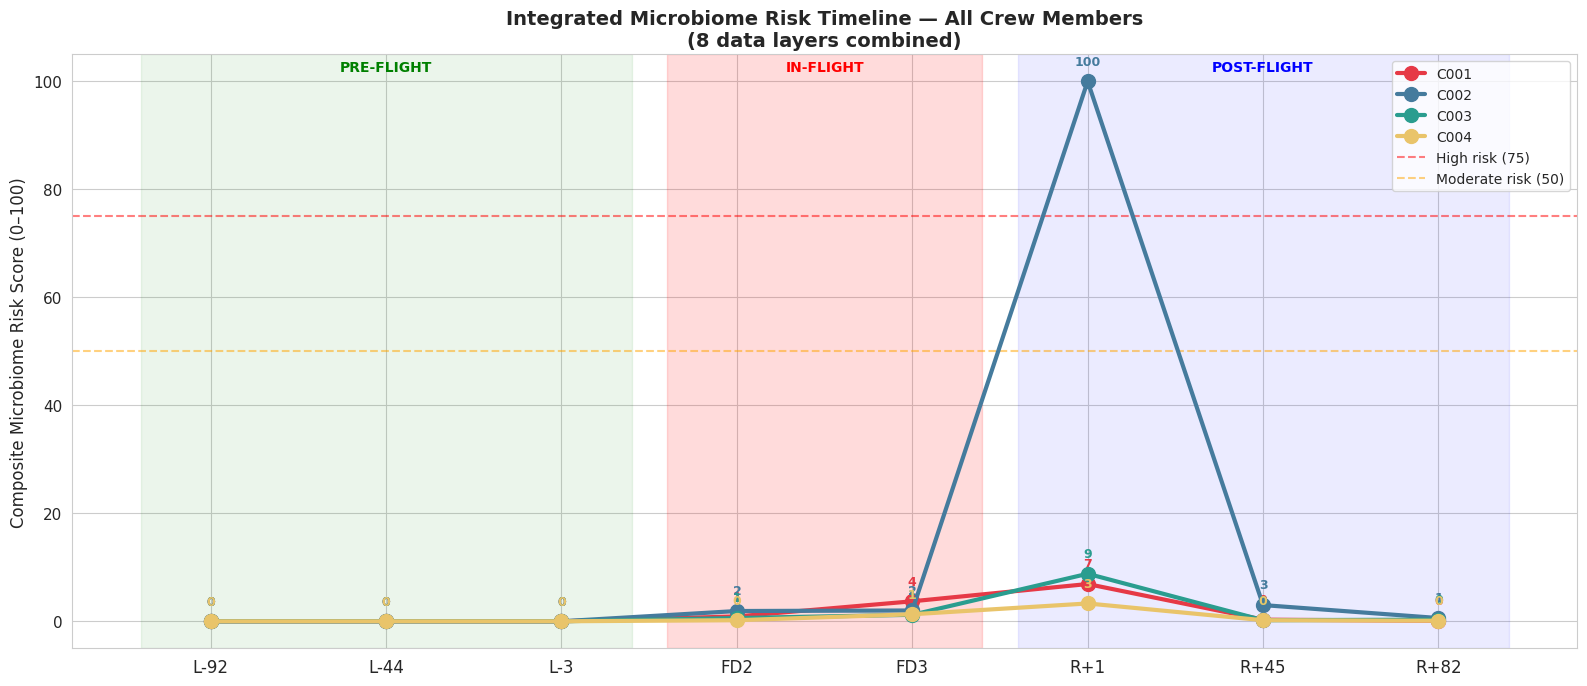

Saved: composite_risk_all_datasets.png


In [ ]:
# Equal-weight composite across all available microbiome deviation scores
available_keys = list(deviation_registry.keys())
n = len(available_keys)

composite = pd.DataFrame(index=CREW_IDS, columns=TIMEPOINT_ORDER, dtype=float)
for crew in CREW_IDS:
    for tp in TIMEPOINT_ORDER:
        scores = []
        for key in available_keys:
            dev_df = deviation_registry[key]
            if tp in dev_df.columns and not np.isnan(dev_df.loc[crew, tp]):
                scores.append(dev_df.loc[crew, tp])
        composite.loc[crew, tp] = np.mean(scores) if scores else np.nan

composite = composite.astype(float)
max_val = composite.max().max()
composite_norm = (composite / max_val * 100).round(1)

# Plot composite risk timeline
fig, ax = plt.subplots(figsize=(16, 7))
avail_tps = [tp for tp in TIMEPOINT_ORDER if not composite_norm[tp].isna().all()]

for crew in CREW_IDS:
    y = [composite_norm.loc[crew, tp] for tp in avail_tps]
    ax.plot(range(len(avail_tps)), y, marker='o', linewidth=3,
            color=COLORS[crew], label=crew, markersize=10, zorder=3)
    for i, val in enumerate(y):
        if not np.isnan(val):
            ax.annotate(f'{val:.0f}', (i, val), textcoords='offset points',
                        xytext=(0, 12), ha='center', fontsize=9, color=COLORS[crew], fontweight='bold')

tp_idx = {tp: i for i, tp in enumerate(avail_tps)}
pre_r  = [tp_idx[t] for t in PRE_FLIGHT  if t in tp_idx]
in_r   = [tp_idx[t] for t in IN_FLIGHT   if t in tp_idx]
post_r = [tp_idx[t] for t in POST_FLIGHT if t in tp_idx]
if pre_r:  ax.axvspan(min(pre_r)-0.4,  max(pre_r)+0.4,  alpha=0.08, color='green')
if in_r:   ax.axvspan(min(in_r)-0.4,   max(in_r)+0.4,   alpha=0.14, color='red')
if post_r: ax.axvspan(min(post_r)-0.4, max(post_r)+0.4, alpha=0.08, color='blue')

ax.axhline(75, color='red',    linestyle='--', alpha=0.5, linewidth=1.5, label='High risk (75)')
ax.axhline(50, color='orange', linestyle='--', alpha=0.5, linewidth=1.5, label='Moderate risk (50)')

ylim = ax.get_ylim()
if pre_r:  ax.text(np.mean(pre_r),  ylim[1]*0.97, 'PRE-FLIGHT',  ha='center', color='green', fontsize=10, fontweight='bold')
if in_r:   ax.text(np.mean(in_r),   ylim[1]*0.97, 'IN-FLIGHT',   ha='center', color='red',   fontsize=10, fontweight='bold')
if post_r: ax.text(np.mean(post_r), ylim[1]*0.97, 'POST-FLIGHT', ha='center', color='blue',  fontsize=10, fontweight='bold')

ax.set_xticks(range(len(avail_tps)))
ax.set_xticklabels(avail_tps, fontsize=12)
ax.set_ylabel('Composite Microbiome Risk Score (0–100)', fontsize=12)
ax.set_title(f'Integrated Microbiome Risk Timeline — All Crew Members\n({n} data layers combined)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('composite_risk_all_datasets.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: composite_risk_all_datasets.png')

## 5. Body Site Heatmaps — Where Did Each Person Change Most?


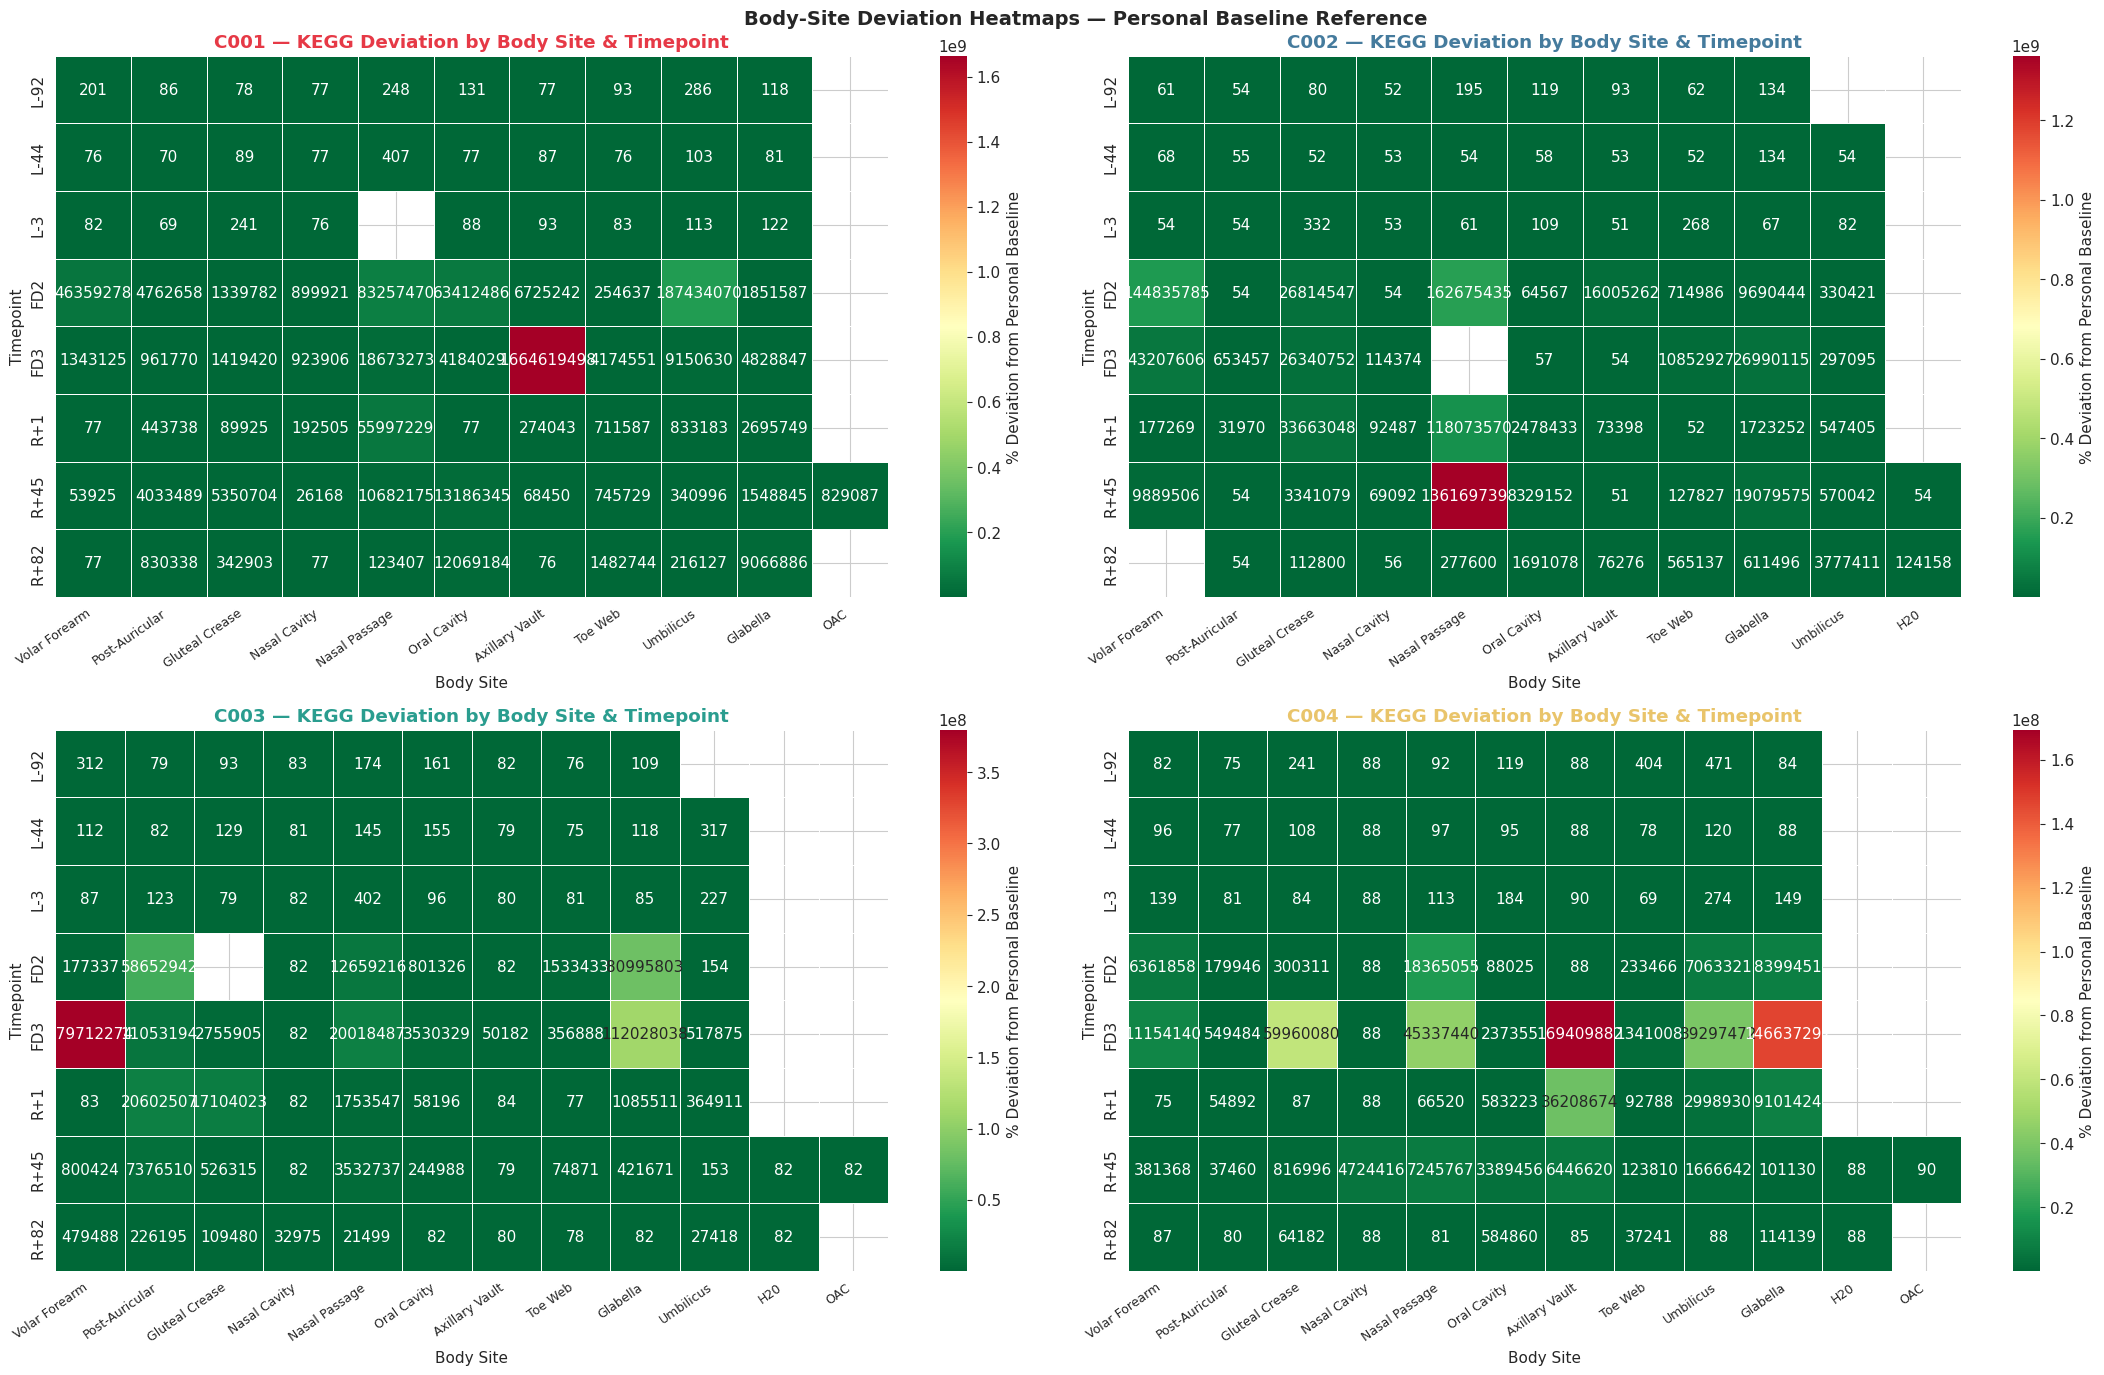

In [ ]:
def site_deviation_matrix(df, crew_id):
    baseline = personal_baseline(df, crew_id)
    rows = []
    for tp in TIMEPOINT_ORDER:
        cols = tp_cols(df, crew_id, tp)
        if not cols: continue
        row = {'timepoint': tp}
        for col in cols:
            parts = str(col).split('_')
            site = parts[2] if len(parts) >= 3 else 'UNK'
            row[SITE_NAMES.get(site, site)] = deviation_score(df[col], baseline)
        rows.append(row)
    return pd.DataFrame(rows).set_index('timepoint') if rows else pd.DataFrame()

fig, axes = plt.subplots(2, 2, figsize=(22, 14))
axes = axes.flatten()
for ax, crew in zip(axes, CREW_IDS):
    mat = site_deviation_matrix(kegg_swab, crew)
    if mat.empty:
        ax.set_title(f'{crew} — No data'); continue
    sns.heatmap(mat, ax=ax, cmap='RdYlGn_r', annot=True, fmt='.0f',
                linewidths=0.5, cbar_kws={'label': '% Deviation from Personal Baseline'})
    ax.set_title(f'{crew} — KEGG Deviation by Body Site & Timepoint', fontweight='bold', color=COLORS[crew])
    ax.set_xlabel('Body Site'); ax.set_ylabel('Timepoint')
    plt.setp(ax.get_xticklabels(), rotation=35, ha='right', fontsize=9)
plt.suptitle('Body-Site Deviation Heatmaps — Personal Baseline Reference', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('body_site_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Immune Repertoire Analysis — T-cell & B-cell Clone Dynamics
Track immune clone expansion/contraction across the mission using VDJ data.

=== VDJ IMMUNE REPERTOIRE ANALYSIS ===
Total clones: 258138
Columns: ['SeqName', 'SeqLen', 'GeneType', 'Grouping', 'Species', 'Sequence', 'GermlineSequence', 'ClonalPool', 'TotalMuts', 'Mutations', 'Isotype', 'crewID', 'timepoint']

Clone counts per crew per timepoint:
timepoint   L-3    R+1   R+45   R+82
crewID                              
C001       1192  35220  13324  18047
C002        727  27102  14566  14053
C003         63  28252  22029  16873
C004       1412  28955  15021  21302


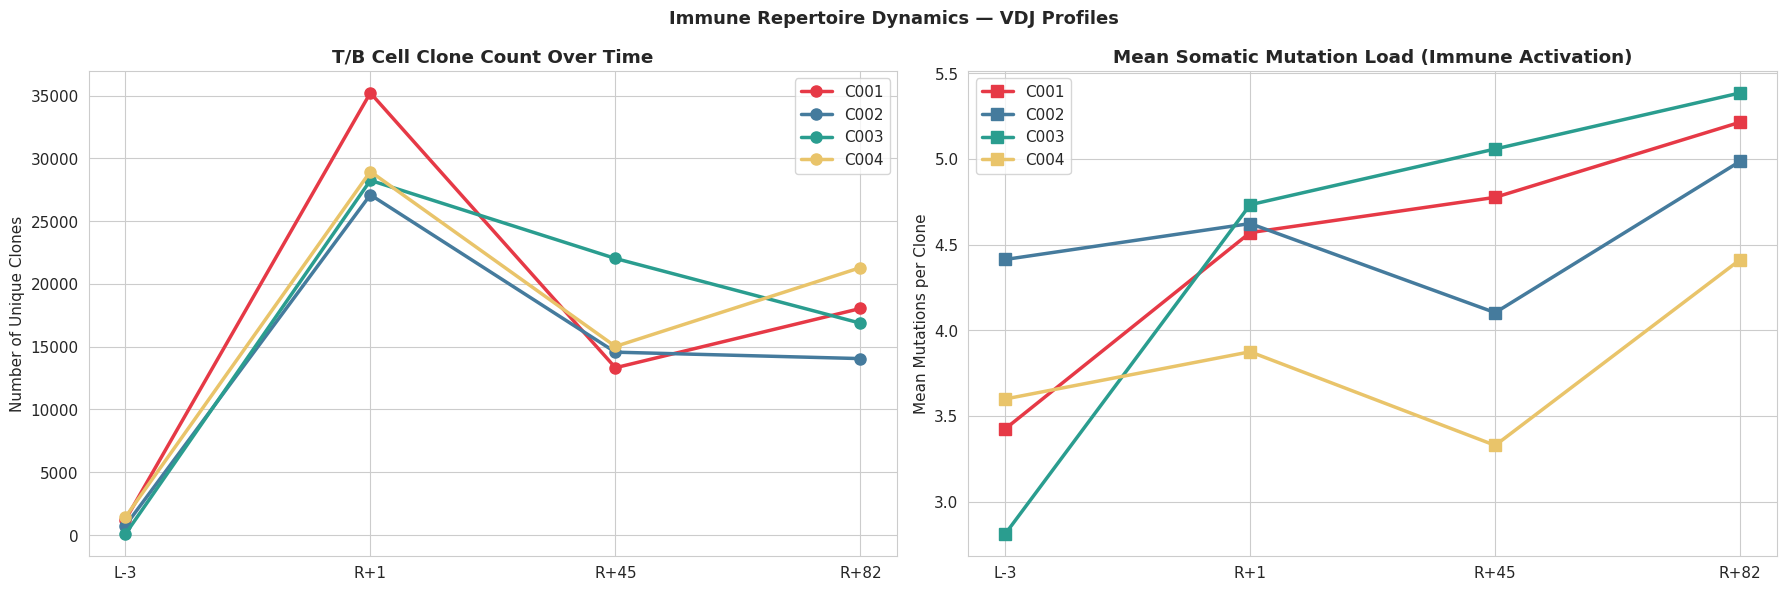

In [ ]:
if vdj is not None:
    print('=== VDJ IMMUNE REPERTOIRE ANALYSIS ===')
    print(f'Total clones: {len(vdj)}')
    print(f'Columns: {list(vdj.columns)}')

    # Clone counts per crew per timepoint
    clone_counts = vdj.groupby(['crewID','timepoint']).size().unstack(fill_value=0)
    print('\nClone counts per crew per timepoint:')
    print(clone_counts)

    # Mutation load (somatic mutations = immune activation signal)
    mutation_load = vdj.groupby(['crewID','timepoint'])['TotalMuts'].mean().unstack(fill_value=np.nan)

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # Clone diversity
    ax = axes[0]
    for crew in CREW_IDS:
        if crew in clone_counts.index:
            tps = [tp for tp in TIMEPOINT_ORDER if tp in clone_counts.columns]
            vals = [clone_counts.loc[crew, tp] if tp in clone_counts.columns else np.nan for tp in tps]
            ax.plot(range(len(tps)), vals, marker='o', linewidth=2.5,
                    color=COLORS[crew], label=crew, markersize=8)
    ax.set_xticks(range(len(tps)))
    ax.set_xticklabels(tps)
    ax.set_title('T/B Cell Clone Count Over Time', fontweight='bold')
    ax.set_ylabel('Number of Unique Clones')
    ax.legend()

    # Mutation load
    ax = axes[1]
    for crew in CREW_IDS:
        if crew in mutation_load.index:
            tps = [tp for tp in TIMEPOINT_ORDER if tp in mutation_load.columns]
            vals = [mutation_load.loc[crew, tp] if tp in mutation_load.columns else np.nan for tp in tps]
            ax.plot(range(len(tps)), vals, marker='s', linewidth=2.5,
                    color=COLORS[crew], label=crew, markersize=8)
    ax.set_xticks(range(len(tps)))
    ax.set_xticklabels(tps)
    ax.set_title('Mean Somatic Mutation Load (Immune Activation)', fontweight='bold')
    ax.set_ylabel('Mean Mutations per Clone')
    ax.legend()

    plt.suptitle('Immune Repertoire Dynamics — VDJ Profiles', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('vdj_immune_repertoire.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('VDJ data not available')

## 7. Gene Expression Analysis — Blood RNA-seq
Which human genes were most differentially expressed across the mission?

=== BLOOD RNA-SEQ ANALYSIS ===
DESeq2 columns: ['DESeq2_log2FC', 'DESeq2_p-value', 'DESeq2_adjusted p-value', 'pipeline-transcriptome-de_log2FC']
Significant DEGs (padj<0.05, |log2FC|>1): 0


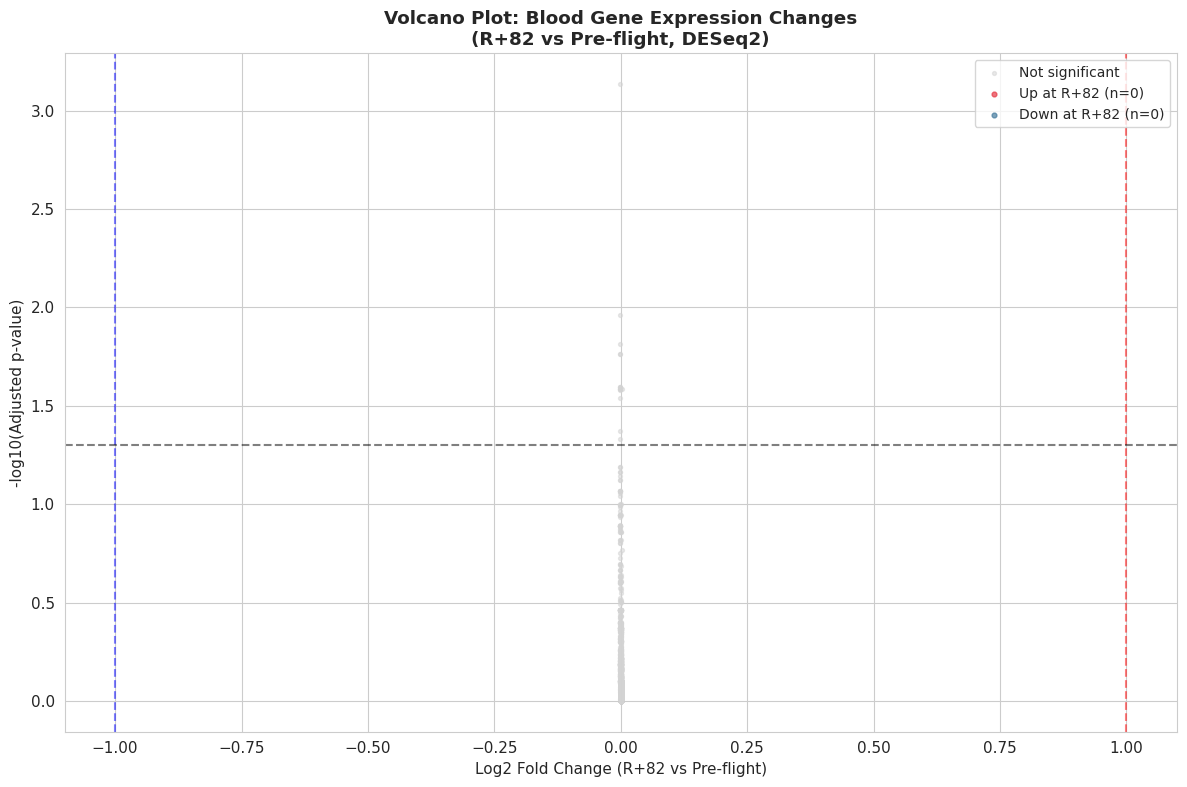

In [ ]:
if rna_blood is not None:
    print('=== BLOOD RNA-SEQ ANALYSIS ===')

    # Get DESeq2 results
    deseq_cols = [c for c in rna_blood.columns if 'DESeq2' in str(c) or 'log2FC' in str(c) or 'pvalue' in str(c).lower()]
    print(f'DESeq2 columns: {deseq_cols}')

    # Find log2FC and p-value columns
    lfc_col = next((c for c in rna_blood.columns if 'log2FC' in str(c) and 'DESeq2' in str(c)), None)
    pval_col = next((c for c in rna_blood.columns if 'adjusted' in str(c).lower() and 'DESeq2' in str(c)), None)

    if lfc_col and pval_col:
        sig = rna_blood[(rna_blood[pval_col] < 0.05) & (rna_blood[lfc_col].abs() > 1)].copy()
        sig = sig.dropna(subset=[lfc_col, pval_col])
        print(f'Significant DEGs (padj<0.05, |log2FC|>1): {len(sig)}')

        # Volcano plot
        fig, ax = plt.subplots(figsize=(12, 8))
        all_genes = rna_blood.dropna(subset=[lfc_col, pval_col])
        neg_log_p = -np.log10(all_genes[pval_col].replace(0, 1e-300))

        up   = all_genes[(all_genes[lfc_col] > 1)  & (all_genes[pval_col] < 0.05)]
        down = all_genes[(all_genes[lfc_col] < -1) & (all_genes[pval_col] < 0.05)]
        ns   = all_genes[~all_genes.index.isin(up.index.tolist() + down.index.tolist())]

        ax.scatter(ns[lfc_col],   -np.log10(ns[pval_col].replace(0,1e-300)),   c='lightgrey', s=8, alpha=0.5, label='Not significant')
        ax.scatter(up[lfc_col],   -np.log10(up[pval_col].replace(0,1e-300)),   c='#E63946',   s=12, alpha=0.7, label=f'Up at R+82 (n={len(up)})')
        ax.scatter(down[lfc_col], -np.log10(down[pval_col].replace(0,1e-300)), c='#457B9D',   s=12, alpha=0.7, label=f'Down at R+82 (n={len(down)})')

        # Label top 10 most significant
        top_sig = sig.nsmallest(10, pval_col)
        for gene, row in top_sig.iterrows():
            gene_label = str(gene).split('.')[0]
            ax.annotate(gene_label, (row[lfc_col], -np.log10(row[pval_col]+1e-300)),
                        fontsize=7, ha='center', xytext=(5,5), textcoords='offset points')

        ax.axvline(1,  color='red',   linestyle='--', alpha=0.5)
        ax.axvline(-1, color='blue',  linestyle='--', alpha=0.5)
        ax.axhline(-np.log10(0.05), color='black', linestyle='--', alpha=0.5)
        ax.set_xlabel('Log2 Fold Change (R+82 vs Pre-flight)')
        ax.set_ylabel('-log10(Adjusted p-value)')
        ax.set_title('Volcano Plot: Blood Gene Expression Changes\n(R+82 vs Pre-flight, DESeq2)', fontweight='bold')
        ax.legend(fontsize=10)
        plt.tight_layout()
        plt.savefig('rnaseq_volcano.png', dpi=150, bbox_inches='tight')
        plt.show()
else:
    print('RNA-seq data not available')

## 8. Gut vs Body Microbiome Comparison
Compare gut (stool) microbiome deviation with body surface microbiome deviation.
The gut is often a leading indicator of systemic health.

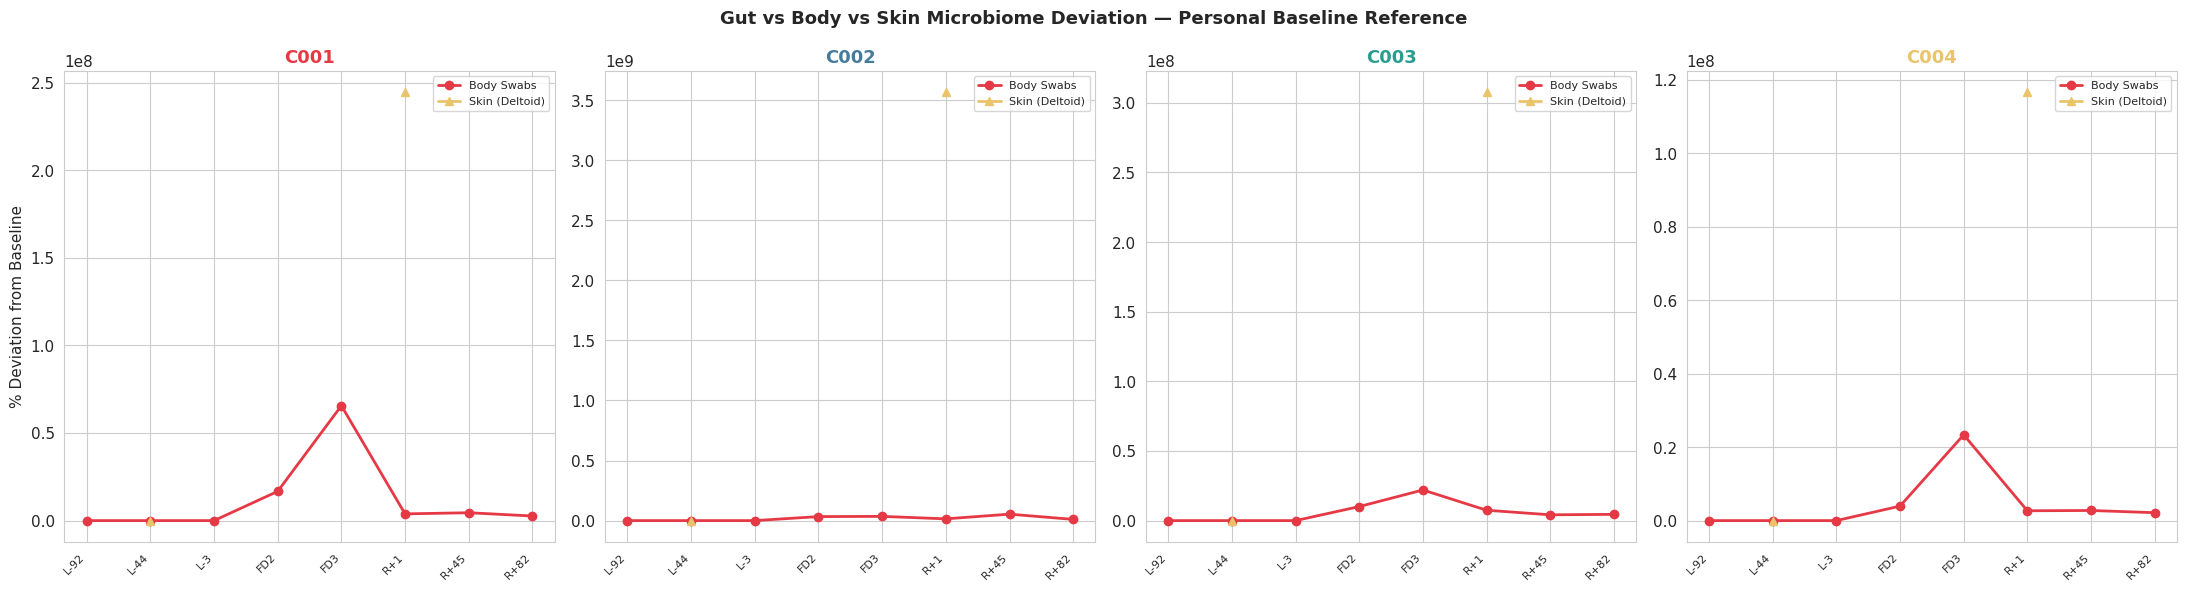

In [ ]:
body_keys = [k for k in deviation_registry if 'Body swab' in k]
gut_keys  = [k for k in deviation_registry if 'Stool' in k]
skin_keys = [k for k in deviation_registry if 'Skin' in k]

def mean_deviation(keys, crew, tp):
    scores = []
    for k in keys:
        df = deviation_registry[k]
        if tp in df.columns and not np.isnan(df.loc[crew, tp]):
            scores.append(df.loc[crew, tp])
    return np.mean(scores) if scores else np.nan

if body_keys or gut_keys:
    fig, axes = plt.subplots(1, 4, figsize=(22, 6), sharey=False)
    for ax, crew in zip(axes, CREW_IDS):
        avail = [tp for tp in TIMEPOINT_ORDER]
        body_scores = [mean_deviation(body_keys, crew, tp) for tp in avail]
        gut_scores  = [mean_deviation(gut_keys, crew, tp) for tp in avail]
        skin_scores = [mean_deviation(skin_keys, crew, tp) for tp in avail]
        x = range(len(avail))

        if any(not np.isnan(v) for v in body_scores):
            ax.plot(x, body_scores, marker='o', label='Body Swabs', color='#E63946', linewidth=2)
        if any(not np.isnan(v) for v in gut_scores):
            ax.plot(x, gut_scores, marker='s', label='Gut (Stool)', color='#2A9D8F', linewidth=2)
        if any(not np.isnan(v) for v in skin_scores):
            ax.plot(x, skin_scores, marker='^', label='Skin (Deltoid)', color='#E9C46A', linewidth=2)

        ax.set_xticks(list(x))
        ax.set_xticklabels(avail, rotation=45, ha='right', fontsize=8)
        ax.set_title(crew, fontweight='bold', color=COLORS[crew], fontsize=13)
        ax.set_ylabel('% Deviation from Baseline' if crew == 'C001' else '')
        ax.legend(fontsize=8)

    plt.suptitle('Gut vs Body vs Skin Microbiome Deviation — Personal Baseline Reference',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('gut_vs_body_microbiome.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No gut or body microbiome data available for comparison')

## 9. Per-Astronaut Full Risk Summary
Combine ALL available signals into one comprehensive profile per crew member.

In [ ]:
def full_risk_summary(crew_id):
    print(f"\n{'='*65}")
    print(f" ASTRONAUT {crew_id} — COMPREHENSIVE RISK PROFILE")
    print(f"{'='*65}")

    # Composite microbiome scores
    peak_inflight, latest_post, latest_tp = np.nan, np.nan, 'N/A'
    if not composite_norm.empty:
        in_scores  = {tp: composite_norm.loc[crew_id,tp] for tp in IN_FLIGHT   if tp in composite_norm.columns and not np.isnan(composite_norm.loc[crew_id,tp])}
        post_scores = {tp: composite_norm.loc[crew_id,tp] for tp in POST_FLIGHT if tp in composite_norm.columns and not np.isnan(composite_norm.loc[crew_id,tp])}
        peak_inflight = max(in_scores.values()) if in_scores else np.nan
        if post_scores:
            latest_tp = list(post_scores.keys())[-1]
            latest_post = post_scores[latest_tp]

    risk_lvl = ('🔴 HIGH' if not np.isnan(peak_inflight) and peak_inflight >= 75 else
                '🟡 MODERATE' if not np.isnan(peak_inflight) and peak_inflight >= 50 else
                '🟢 LOW' if not np.isnan(peak_inflight) else '⚪ UNKNOWN')
    rec_status = ('✅ GOOD' if not np.isnan(latest_post) and latest_post < 25 else
                  '⚠️  PARTIAL' if not np.isnan(latest_post) and latest_post < 50 else
                  '🚨 POOR' if not np.isnan(latest_post) else '⚪ UNKNOWN')

    print(f"\n🦠 MICROBIOME")
    print(f"   In-flight disruption: {risk_lvl} ({peak_inflight:.1f}/100)")
    print(f"   Recovery @ {latest_tp}: {rec_status} ({latest_post:.1f}/100)")

    # Body site breakdown
    if body_keys:
        print(f"\n📍 MOST AFFECTED BODY SITES (in-flight):")
        site_scores = {}
        for tp in IN_FLIGHT:
            for col in tp_cols(kegg_swab, crew_id, tp):
                site = str(col).split('_')[2] if len(str(col).split('_')) >= 3 else 'UNK'
                baseline = personal_baseline(kegg_swab, crew_id)
                dev = deviation_score(kegg_swab[col], baseline)
                site_scores[SITE_NAMES.get(site, site)] = site_scores.get(SITE_NAMES.get(site,site), []) + [dev]
        site_means = {s: np.mean(v) for s, v in site_scores.items()}
        for site, score in sorted(site_means.items(), key=lambda x: -x[1])[:5]:
            print(f"   {site}: {score:.1f}% deviation")

    # VDJ immune
    if vdj is not None:
        crew_vdj = vdj[vdj['crewID'] == crew_id]
        tp_clones = crew_vdj.groupby('timepoint').size()
        print(f"\n🛡️  IMMUNE REPERTOIRE (T/B cell clones):")
        for tp, n in tp_clones.items():
            print(f"   {tp}: {n} unique clones")
        avg_muts = crew_vdj.groupby('timepoint')['TotalMuts'].mean()
        print(f"   Avg somatic mutations: {avg_muts.to_dict()}")

    # RNA-seq summary
    if rna_blood is not None:
        crew_rna_cols = [c for c in rna_blood.columns if str(crew_id) in str(c)]
        print(f"\n🧬 BLOOD RNA-seq: {len(crew_rna_cols)} sample columns available")

    # Recommendations
    print(f"\n📋 PREPARATION RECOMMENDATIONS FOR FUTURE MISSIONS:")
    recs = []
    if not np.isnan(peak_inflight) and peak_inflight >= 75:
        recs.append('  • HIGH disruption detected — pre-flight microbiome stabilization protocol strongly advised')
    if not np.isnan(latest_post) and latest_post >= 50:
        recs.append(f'  • Incomplete recovery at {latest_tp} — extend post-flight monitoring to R+180')
    if vdj is not None:
        crew_vdj = vdj[vdj['crewID'] == crew_id]
        if crew_vdj['TotalMuts'].mean() > 1:
            recs.append('  • Elevated immune mutation load — consider immune function testing pre-mission')
    recs.append('  • Collect complete pre-flight baseline (L-92, L-44, L-3) for all biomarker layers')
    recs.append('  • Ensure post-flight collection includes R+194 for full recovery assessment')
    for r in recs:
        print(r)

for crew in CREW_IDS:
    full_risk_summary(crew)


 ASTRONAUT C001 — COMPREHENSIVE RISK PROFILE

🦠 MICROBIOME
   In-flight disruption: 🟢 LOW (3.7/100)
   Recovery @ R+82: ✅ GOOD (0.1/100)

📍 MOST AFFECTED BODY SITES (in-flight):
   Axillary Vault: 835672370.3% deviation
   Umbilicus: 98292349.8% deviation
   Nasal Passage: 50965371.4% deviation
   Oral Cavity: 33798257.3% deviation
   Volar Forearm: 23851201.7% deviation

🛡️  IMMUNE REPERTOIRE (T/B cell clones):
   L-3: 1192 unique clones
   R+1: 35220 unique clones
   R+45: 13324 unique clones
   R+82: 18047 unique clones
   Avg somatic mutations: {'L-3': 3.4236577181208054, 'R+1': 4.569505962521295, 'R+45': 4.775442809966977, 'R+82': 5.213996786169447}

🧬 BLOOD RNA-seq: 8 sample columns available

📋 PREPARATION RECOMMENDATIONS FOR FUTURE MISSIONS:
  • Elevated immune mutation load — consider immune function testing pre-mission
  • Collect complete pre-flight baseline (L-92, L-44, L-3) for all biomarker layers
  • Ensure post-flight collection includes R+194 for full recovery assessm

## 10. Cross-Crew Resilience Comparison
Who handled spaceflight best? Who needs the most preparation support?

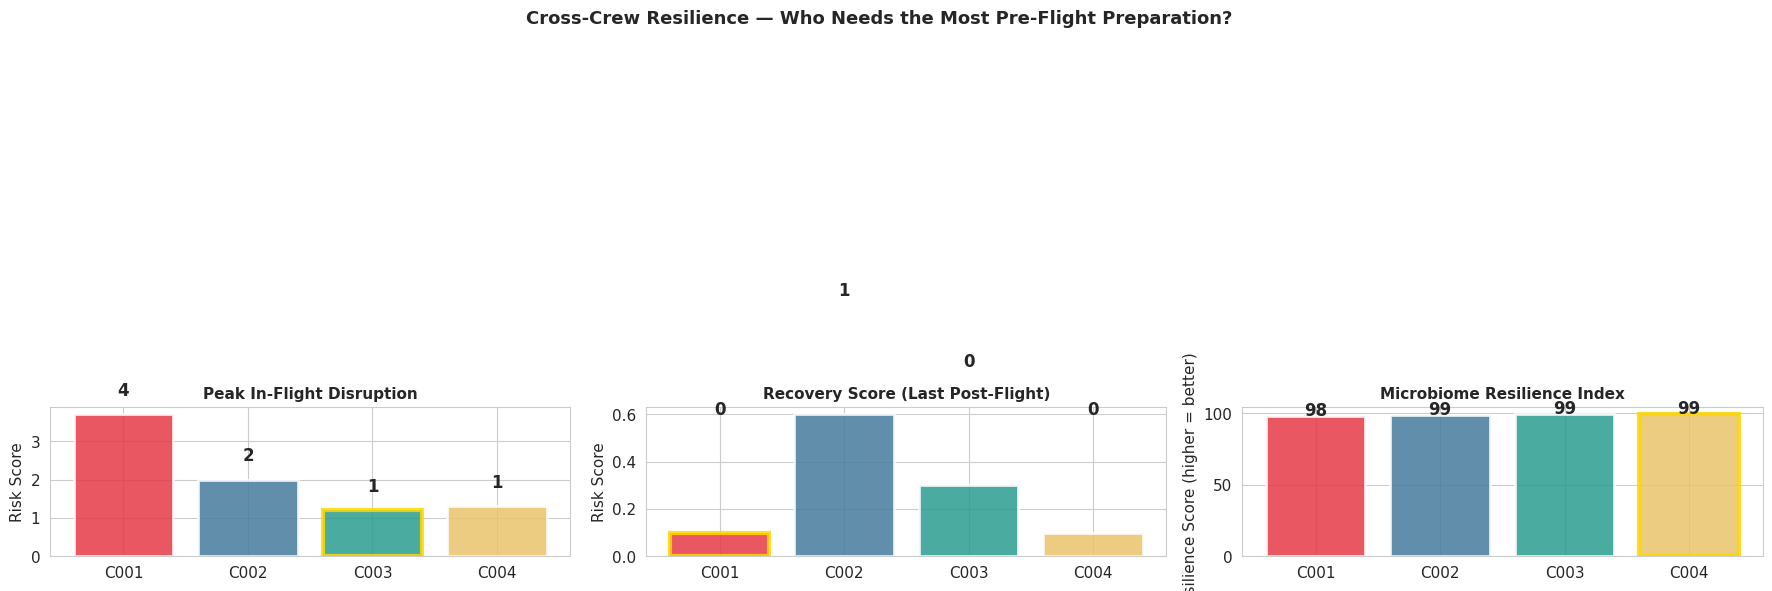

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

peaks, recoveries, resilience = [], [], []
for crew in CREW_IDS:
    in_s  = [composite_norm.loc[crew, tp] for tp in IN_FLIGHT   if tp in composite_norm.columns and not np.isnan(composite_norm.loc[crew, tp])]
    post_s= [composite_norm.loc[crew, tp] for tp in POST_FLIGHT if tp in composite_norm.columns and not np.isnan(composite_norm.loc[crew, tp])]
    p = max(in_s) if in_s else np.nan
    r = post_s[-1] if post_s else np.nan
    peaks.append(p)
    recoveries.append(r)
    resilience.append(100 - (0.5*p + 0.5*r) if not (np.isnan(p) or np.isnan(r)) else np.nan)

for ax, (title, vals, ylabel) in zip(axes, [
    ('Peak In-Flight Disruption', peaks, 'Risk Score'),
    ('Recovery Score (Last Post-Flight)', recoveries, 'Risk Score'),
    ('Microbiome Resilience Index', resilience, 'Resilience Score (higher = better)')
]):
    bars = ax.bar(CREW_IDS, vals, color=[COLORS[c] for c in CREW_IDS], alpha=0.85, edgecolor='white', linewidth=2)
    for bar, val in zip(bars, vals):
        if val and not np.isnan(val):
            ax.text(bar.get_x()+bar.get_width()/2, val+0.5, f'{val:.0f}',
                    ha='center', fontsize=12, fontweight='bold')
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_ylabel(ylabel)

    if not all(np.isnan(v) for v in vals if v is not None):
        clean = [(i,v) for i,v in enumerate(vals) if v is not None and not np.isnan(v)]
        if clean:
            best_i = (max if 'Resilience' in title else min)(clean, key=lambda x: x[1])[0]
            bars[best_i].set_edgecolor('gold')
            bars[best_i].set_linewidth(3)

plt.suptitle('Cross-Crew Resilience — Who Needs the Most Pre-Flight Preparation?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('resilience_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Export All Results

In [ ]:
import os
os.makedirs('outputs', exist_ok=True)

# Save all deviation tables
for key, dev_df in deviation_registry.items():
    fname = key.lower().replace(' ','_').replace('/','_')
    dev_df.to_csv(f'outputs/deviation_{fname}.csv')
    print(f'Saved: outputs/deviation_{fname}.csv')

# Save composite risk
composite_norm.to_csv('outputs/composite_risk_scores.csv')
print('Saved: outputs/composite_risk_scores.csv')

# Save VDJ summary
if vdj is not None:
    vdj.groupby(['crewID','timepoint']).size().to_csv('outputs/vdj_clone_counts.csv')
    print('Saved: outputs/vdj_clone_counts.csv')

print('\n✅ All outputs saved to outputs/')
print('📁 Figures saved: composite_risk_all_datasets.png, body_site_heatmaps.png,')
print('                  vdj_immune_repertoire.png, rnaseq_volcano.png,')
print('                  gut_vs_body_microbiome.png, resilience_comparison.png')

Saved: outputs/deviation_body_swab_kegg.csv
Saved: outputs/deviation_body_swab_taxonomy.csv
Saved: outputs/deviation_body_swab_pathways.csv
Saved: outputs/deviation_body_swab_genefam.csv
Saved: outputs/deviation_skin_genefam.csv
Saved: outputs/deviation_skin_kegg.csv
Saved: outputs/deviation_skin_pathways.csv
Saved: outputs/deviation_skin_taxonomy.csv
Saved: outputs/composite_risk_scores.csv
Saved: outputs/vdj_clone_counts.csv

✅ All outputs saved to outputs/
📁 Figures saved: composite_risk_all_datasets.png, body_site_heatmaps.png,
                  vdj_immune_repertoire.png, rnaseq_volcano.png,
                  gut_vs_body_microbiome.png, resilience_comparison.png
